In [15]:
"""
Heterogeneous Fire Effects: Size, Severity, and Vegetation
===========================================================
Estimates how fire effects vary by:
- Fire size (small/medium/large terciles)
- Fire severity (low/moderate/high, grass auto-classified as low)
- Vegetation type (grass/shrub/tree)
"""

import pandas as pd
import numpy as np
import re
import warnings

# Suppress pyfixest multicollinearity warnings (expected in staggered DiD)
warnings.filterwarnings('ignore', message='.*variables dropped due to multicollinearity.*')
warnings.filterwarnings('ignore', module='pyfixest')

# ============================================================
# YOUR DATA FILES
# ============================================================

# Colorado
CO_PRED = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\GitHub\Data\TreatCon_Pred_CO.csv"
CO_FIRE = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\GitHub\Data\fire_feature_matrix_CO.csv"

# California
CA_PRED = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\GitHub\Data\TreatCon_Pred_CA.csv"
CA_FIRE = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\GitHub\Data\fire_feature_matrix_CA.csv"

# Where to save results
OUTPUT = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\did_heterogeneity_results.csv"

# ============================================================
# ANALYSIS SETTINGS
# ============================================================

MONTHS_PRE_FIRE = 12
REFERENCE_MONTH = -2
MIN_SAMPLE_PERCENT = 0.10

# Control variables
CONTROLS = ['temperature_mean']

# ============================================================
# CLASSIFICATION FUNCTIONS
# ============================================================

def classify_treatment_co(treatment_type):
    """Colorado treatment classification"""
    if pd.isna(treatment_type):
        return 'unknown'
    tt = str(treatment_type).lower()
    if 'fire' in tt and 'control' not in tt:
        return 'wildfire_treated'
    elif 'controlfire' in tt:
        return 'wildfire_control'
    elif 'rx' in tt and 'control' not in tt:
        return 'rx_treated'
    elif 'controlrx' in tt:
        return 'rx_control'
    return 'unknown'

def classify_treatment_ca(treatment_type):
    """California treatment classification"""
    if pd.isna(treatment_type):
        return "unknown"
    tt = str(treatment_type).lower()
    if "wildfire" in tt and "treated" in tt:
        return "wildfire_treated"
    elif "wildfire" in tt and "control" in tt:
        return "wildfire_control"
    elif "rx" in tt and "treated" in tt:
        return "rx_treated"
    elif "rx" in tt and "control" in tt:
        return "rx_control"
    return "unknown"

def classify_vegetation(row):
    """Classify dominant vegetation type"""
    def safe_float(val):
        if val is None or pd.isna(val):
            return 0.0
        try:
            return float(val)
        except:
            return 0.0
    
    grass = safe_float(row.get('grass_pct_mean', 0))
    shrub = safe_float(row.get('shrub_pct_mean', 0))
    tree = safe_float(row.get('tree_pct_mean', 0))
    
    if grass == 0 and shrub == 0 and tree == 0:
        return 'unknown'
    
    veg_dict = {'grass': grass, 'shrub': shrub, 'tree': tree}
    return max(veg_dict, key=veg_dict.get)

def classify_severity(row, veg_type=None):
    """
    Classify fire severity
    Grass fires auto-classified as low (CBI not ecologically meaningful for grass)
    """
    if veg_type == 'grass':
        return 'low'
    
    def safe_float(val):
        if val is None or pd.isna(val):
            return 0.0
        try:
            return float(val)
        except:
            return 0.0
    
    pct_high = safe_float(row.get('pct_high_severity', 0))
    pct_mod = safe_float(row.get('pct_moderate_severity', 0))
    
    if pct_high > 0.33:
        return 'high'
    if (pct_mod + pct_high) > 0.33:
        return 'moderate'
    return 'low'

def calculate_size_terciles(df):
    """Calculate fire size terciles"""
    treated = df[df['treated'] == 1].copy()
    sizes = treated[treated['area_km2'].notna()]['area_km2'].values
    if len(sizes) < 3:
        return None
    return np.percentile(sizes, [33.33, 66.67])

def classify_fire_size(size, breaks):
    """Classify fire size based on terciles"""
    if breaks is None or pd.isna(size):
        return 'unknown'
    size = float(size)
    if size <= breaks[0]:
        return 'small'
    elif size <= breaks[1]:
        return 'medium'
    return 'large'

# ============================================================
# DiD ESTIMATION
# ============================================================

def estimate_fire_effect(df, fire_type, controls, severity=None, vegetation=None, size_class=None):
    """
    Estimate monthly DiD effects with optional stratification
    
    Stratification: treated group filtered, control group stays full pool
    """
    try:
        import pyfixest as pf
    except ImportError:
        raise ImportError("Install pyfixest: pip install pyfixest")
    
    # Filter by fire type
    if fire_type == 'wildfire':
        panel = df[df['family'].isin(['wildfire_treated', 'wildfire_control'])].copy()
    else:
        panel = df[df['family'].isin(['rx_treated', 'rx_control'])].copy()
    
    # Get full control pool BEFORE stratification
    full_control = panel[panel['treated'] == 0].copy()
    
    # Apply stratification to TREATED ONLY
    if size_class:
        treated = panel[(panel['treated'] == 1) & (panel['size_class'] == size_class)]
        panel = pd.concat([treated, full_control])
    elif severity:
        treated = panel[(panel['treated'] == 1) & (panel['severity_class'] == severity)]
        panel = pd.concat([treated, full_control])
    elif vegetation:
        treated = panel[(panel['treated'] == 1) & (panel['veg_type'] == vegetation)]
        panel = pd.concat([treated, full_control])
    
    # Time window
    panel = panel[panel['rel_month'].notna()].copy()
    panel = panel[panel['rel_month'] >= -MONTHS_PRE_FIRE].copy()
    panel['rel_month'] = panel['rel_month'].astype(int)
    
    n_treated = panel[panel['treated'] == 1]['siteid'].nunique()
    n_control = panel[panel['treated'] == 0]['siteid'].nunique()
    
    if n_treated < 2 or n_control < 1:
        return None, None, None, None
    
    # Baseline mean
    baseline = panel[(panel['treated'] == 1) & (panel['rel_month'] < 0)]['outcome'].mean()
    if pd.isna(baseline) or baseline == 0:
        baseline = panel['outcome'].mean()
    
    # Build formula
    available_controls = [c for c in controls if c in panel.columns]
    control_term = " + ".join(available_controls) if available_controls else "1"
    formula = f"outcome ~ i(rel_month, treated, ref={REFERENCE_MONTH}) + {control_term} | siteid + time_period"
    
    # Run regression
    model = pf.feols(formula, data=panel, vcov='HC1')
    coef_dict = model.coef().to_dict()
    se_dict = model.se().to_dict()
    
    # Track sample size per month for filtering
    n_treated_per_month = panel[panel['treated'] == 1].groupby('rel_month')['siteid'].nunique().to_dict()
    
    # Extract effects
    effects = {}
    for name in coef_dict.keys():
        match = re.search(r'\[(-?\d+)\]:treated', str(name))
        if match:
            month = int(match.group(1))
            effects[month] = {
                'coef': float(coef_dict[name]),
                'se': float(se_dict[name]),
                'ci_lower': float(coef_dict[name] - 1.96 * se_dict[name]),
                'ci_upper': float(coef_dict[name] + 1.96 * se_dict[name]),
                'n_treated': n_treated_per_month.get(month, 0)
            }
    
    # Add reference period
    effects[REFERENCE_MONTH] = {
        'coef': 0.0, 'se': 0.0, 'ci_lower': 0.0, 'ci_upper': 0.0, 'n_treated': 0
    }
    
    return dict(sorted(effects.items())), n_treated, n_control, baseline

def aggregate_to_years(monthly_effects):
    """Aggregate monthly to annual using inverse-variance weighting"""
    if not monthly_effects:
        return None
    
    df = pd.DataFrame.from_dict(monthly_effects, orient='index')
    
    # Find minimum sample threshold
    peak_sample = df['n_treated'].max()
    min_sample = max(1, int(np.floor(peak_sample * MIN_SAMPLE_PERCENT)))
    
    # Keep post-fire months with sufficient sample
    df = df[df.index >= 0]
    df = df[df['n_treated'] >= min_sample]
    
    if len(df) == 0:
        return None
    
    # Assign to years
    df['year'] = np.floor(df.index / 12).astype(int) + 1
    df.loc[df['year'] > 5, 'year'] = 5
    
    # Aggregate by year
    annual = []
    for year, group in df.groupby('year'):
        weights = 1 / (group['se']**2 + 1e-10)
        weights = weights / weights.sum()
        
        coef = (group['coef'] * weights).sum()
        se = 1 / np.sqrt((1 / (group['se']**2 + 1e-10)).sum())
        
        annual.append({
            'year': int(year),
            'coef': coef,
            'se': se,
            'ci_lower': coef - 1.96 * se,
            'ci_upper': coef + 1.96 * se
        })
    
    # Add year 0
    annual.insert(0, {
        'year': 0, 'coef': 0.0, 'se': 0.0, 'ci_lower': 0.0, 'ci_upper': 0.0
    })
    
    return {row['year']: row for row in annual}

def to_percent(effects, baseline):
    """Convert to percentage changes"""
    if baseline == 0:
        return effects
    return {
        year: {
            'coef': (vals['coef'] / baseline) * 100,
            'se': (vals['se'] / baseline) * 100,
            'ci_lower': (vals['ci_lower'] / baseline) * 100,
            'ci_upper': (vals['ci_upper'] / baseline) * 100
        }
        for year, vals in effects.items()
    }

# ============================================================
# LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

def load_state_data(pred_file, fire_file, classifier, state):
    """Load and prepare data"""
    # Load files
    pred = pd.read_csv(pred_file)
    pred.columns = pred.columns.str.strip().str.lower()
    
    fire = pd.read_csv(fire_file)
    fire.columns = fire.columns.str.strip().str.lower()
    
    # Prepare merge columns
    veg_cols = ['grass_pct_mean', 'shrub_pct_mean', 'tree_pct_mean']
    merge_cols = ['siteid', 'year', 'month']
    fire_merge_cols = merge_cols + CONTROLS + veg_cols + ['area_km2', 'pct_high_severity', 'pct_moderate_severity']
    fire_merge_cols = [c for c in fire_merge_cols if c in fire.columns]
    
    # Merge
    df = pred.merge(
        fire[fire_merge_cols].drop_duplicates(subset=merge_cols),
        on=merge_cols, how='left'
    )
    
    # Remove duplicates
    df = df.loc[:, ~df.columns.duplicated()]
    
    # Classifications
    df['family'] = df['treatment_type'].apply(classifier)
    df['treated'] = df['family'].str.contains('treated').astype(int)
    df['outcome'] = df['y_pred']
    df['time_period'] = df['year'].astype(str) + '_' + df['month'].astype(str).str.zfill(2)
    
    # Fill missing controls
    for col in CONTROLS:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    
    # Vegetation classification
    if all(c in df.columns for c in veg_cols):
        veg_by_site = df.groupby('siteid')[veg_cols].first().reset_index()
        veg_by_site['veg_type'] = veg_by_site.apply(classify_vegetation, axis=1)
        if 'veg_type' in df.columns:
            df = df.drop(columns=['veg_type'])
        df = df.merge(veg_by_site[['siteid', 'veg_type']], on='siteid', how='left')
    else:
        df['veg_type'] = 'unknown'
    
    # Severity classification (grass auto-classified as low)
    df['severity_class'] = df.apply(lambda r: classify_severity(r, veg_type=r.get('veg_type')), axis=1)
    
    # Size classification
    if 'area_km2' in df.columns:
        size_breaks = calculate_size_terciles(df)
        if size_breaks is not None:
            size_by_site = df.groupby('siteid')['area_km2'].first().reset_index()
            size_by_site['size_class'] = size_by_site['area_km2'].apply(lambda x: classify_fire_size(x, size_breaks))
            if 'size_class' in df.columns:
                df = df.drop(columns=['size_class'])
            df = df.merge(size_by_site[['siteid', 'size_class']], on='siteid', how='left')
            df.loc[df['treated'] == 0, 'size_class'] = 'control'
        else:
            df['size_class'] = 'unknown'
    else:
        df['size_class'] = 'unknown'
    
    return df

# Load Colorado
print("\nColorado:")
co_df = load_state_data(CO_PRED, CO_FIRE, classify_treatment_co, 'CO')
print(f"  {len(co_df):,} observations, {co_df['siteid'].nunique()} sites")

# Load California
print("\nCalifornia:")
ca_df = load_state_data(CA_PRED, CA_FIRE, classify_treatment_ca, 'CA')
print(f"  {len(ca_df):,} observations, {ca_df['siteid'].nunique()} sites")

# ============================================================
# RUN HETEROGENEITY ANALYSIS
# ============================================================

print("\n" + "=" * 60)
print("ESTIMATING HETEROGENEOUS FIRE EFFECTS")
print("=" * 60)

results = []

for state, data in [('CO', co_df), ('CA', ca_df)]:
    print(f"\n{state}:")
    
    for fire_type in ['wildfire', 'prescribed']:
        print(f"  {fire_type}:")
        
        # Size analysis
        if 'area_km2' in data.columns and data[data['treated'] == 1]['size_class'].nunique() > 1:
            for size in ['small', 'medium', 'large']:
                print(f"    {size}...", end=' ')
                
                monthly, n_t, n_c, baseline = estimate_fire_effect(
                    data, fire_type, CONTROLS, size_class=size
                )
                
                if monthly:
                    annual = aggregate_to_years(monthly)
                    if annual:
                        annual_pct = to_percent(annual, baseline)
                        for year, vals in annual_pct.items():
                            results.append({
                                'state': state,
                                'fire_type': fire_type,
                                'stratification': 'size',
                                'stratum': size,
                                'year': year,
                                'effect_pct': vals['coef'],
                                'ci_lower': vals['ci_lower'],
                                'ci_upper': vals['ci_upper'],
                                'n_treated': n_t,
                                'n_control': n_c
                            })
                        print(f"✓ ({n_t} treated)")
                    else:
                        print("insufficient data")
                else:
                    print("failed")
        else:
            print("    [Skipping size analysis - data not available]")
        
        # Severity analysis
        sev_cols = ['pct_high_severity', 'pct_moderate_severity']
        if all(c in data.columns for c in sev_cols) and data[data['treated'] == 1]['severity_class'].nunique() > 1:
            for severity in ['low', 'moderate', 'high']:
                print(f"    {severity} severity...", end=' ')
                
                monthly, n_t, n_c, baseline = estimate_fire_effect(
                    data, fire_type, CONTROLS, severity=severity
                )
                
                if monthly:
                    annual = aggregate_to_years(monthly)
                    if annual:
                        annual_pct = to_percent(annual, baseline)
                        for year, vals in annual_pct.items():
                            results.append({
                                'state': state,
                                'fire_type': fire_type,
                                'stratification': 'severity',
                                'stratum': severity,
                                'year': year,
                                'effect_pct': vals['coef'],
                                'ci_lower': vals['ci_lower'],
                                'ci_upper': vals['ci_upper'],
                                'n_treated': n_t,
                                'n_control': n_c
                            })
                        print(f"✓ ({n_t} treated)")
                    else:
                        print("insufficient data")
                else:
                    print("failed")
        else:
            print("    [Skipping severity analysis - data not available]")
        
        # Vegetation analysis
        veg_cols = ['grass_pct_mean', 'shrub_pct_mean', 'tree_pct_mean']
        if all(c in data.columns for c in veg_cols) and data[data['treated'] == 1]['veg_type'].nunique() > 1:
            veg_types = ['grass', 'tree'] if state == 'CO' else ['grass', 'shrub', 'tree']
            for veg in veg_types:
                print(f"    {veg}...", end=' ')
                
                monthly, n_t, n_c, baseline = estimate_fire_effect(
                    data, fire_type, CONTROLS, vegetation=veg
                )
                
                if monthly:
                    annual = aggregate_to_years(monthly)
                    if annual:
                        annual_pct = to_percent(annual, baseline)
                        for year, vals in annual_pct.items():
                            results.append({
                                'state': state,
                                'fire_type': fire_type,
                                'stratification': 'vegetation',
                                'stratum': veg,
                                'year': year,
                                'effect_pct': vals['coef'],
                                'ci_lower': vals['ci_lower'],
                                'ci_upper': vals['ci_upper'],
                                'n_treated': n_t,
                                'n_control': n_c
                            })
                        print(f"✓ ({n_t} treated)")
                    else:
                        print("insufficient data")
                else:
                    print("failed")
        else:
            print("    [Skipping vegetation analysis - data not available]")

# ============================================================
# SAVE RESULTS
# ============================================================

print("\n" + "=" * 60)
print("RESULTS")
print("=" * 60)

if len(results) > 0:
    df_results = pd.DataFrame(results)
    df_results.to_csv(OUTPUT, index=False)
    print(f"\n✓ Saved to: {OUTPUT}")
else:
    print("\nNo results generated - data may be missing required columns.")

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)

if len(results) > 0:
    print(f"\nFull results saved to: {OUTPUT}")
    print("Includes all available stratifications: size, severity, vegetation")

LOADING DATA

Colorado:
  8,160 observations, 136 sites

California:
  22,380 observations, 373 sites

ESTIMATING HETEROGENEOUS FIRE EFFECTS

CO:
  wildfire:
    small... ✓ (12 treated)
    medium... ✓ (14 treated)
    large... ✓ (18 treated)
    low severity... ✓ (31 treated)
    moderate severity... ✓ (8 treated)
    high severity... ✓ (5 treated)
    grass... ✓ (27 treated)
    tree... ✓ (17 treated)
  prescribed:
    small... ✓ (10 treated)
    medium... ✓ (8 treated)
    large... ✓ (4 treated)
    low severity... ✓ (22 treated)
    moderate severity... failed
    high severity... failed
    grass... ✓ (8 treated)
    tree... ✓ (14 treated)

CA:
  wildfire:
    small... ✓ (29 treated)
    medium... ✓ (59 treated)
    large... ✓ (53 treated)
    low severity... ✓ (99 treated)
    moderate severity... ✓ (25 treated)
    high severity... ✓ (17 treated)
    grass... ✓ (65 treated)
    shrub... ✓ (10 treated)
    tree... ✓ (66 treated)
  prescribed:
    small... ✓ (29 treated)
    mediu

LOADING RESULTS

✓ Loaded 169 rows from C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\did_heterogeneity_results.csv

States: ['CO' 'CA']
Fire types: ['wildfire' 'prescribed']
Stratifications: ['size' 'severity' 'vegetation']

CREATING FIGURE: HETEROGENEOUS EFFECTS

✓ Saved figures to: C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\final_figures
  • Heterogeneous_Effects.png (600 DPI)
  • Heterogeneous_Effects.pdf (vector)
  • Heterogeneous_Effects_HighRes.png (1200 DPI)


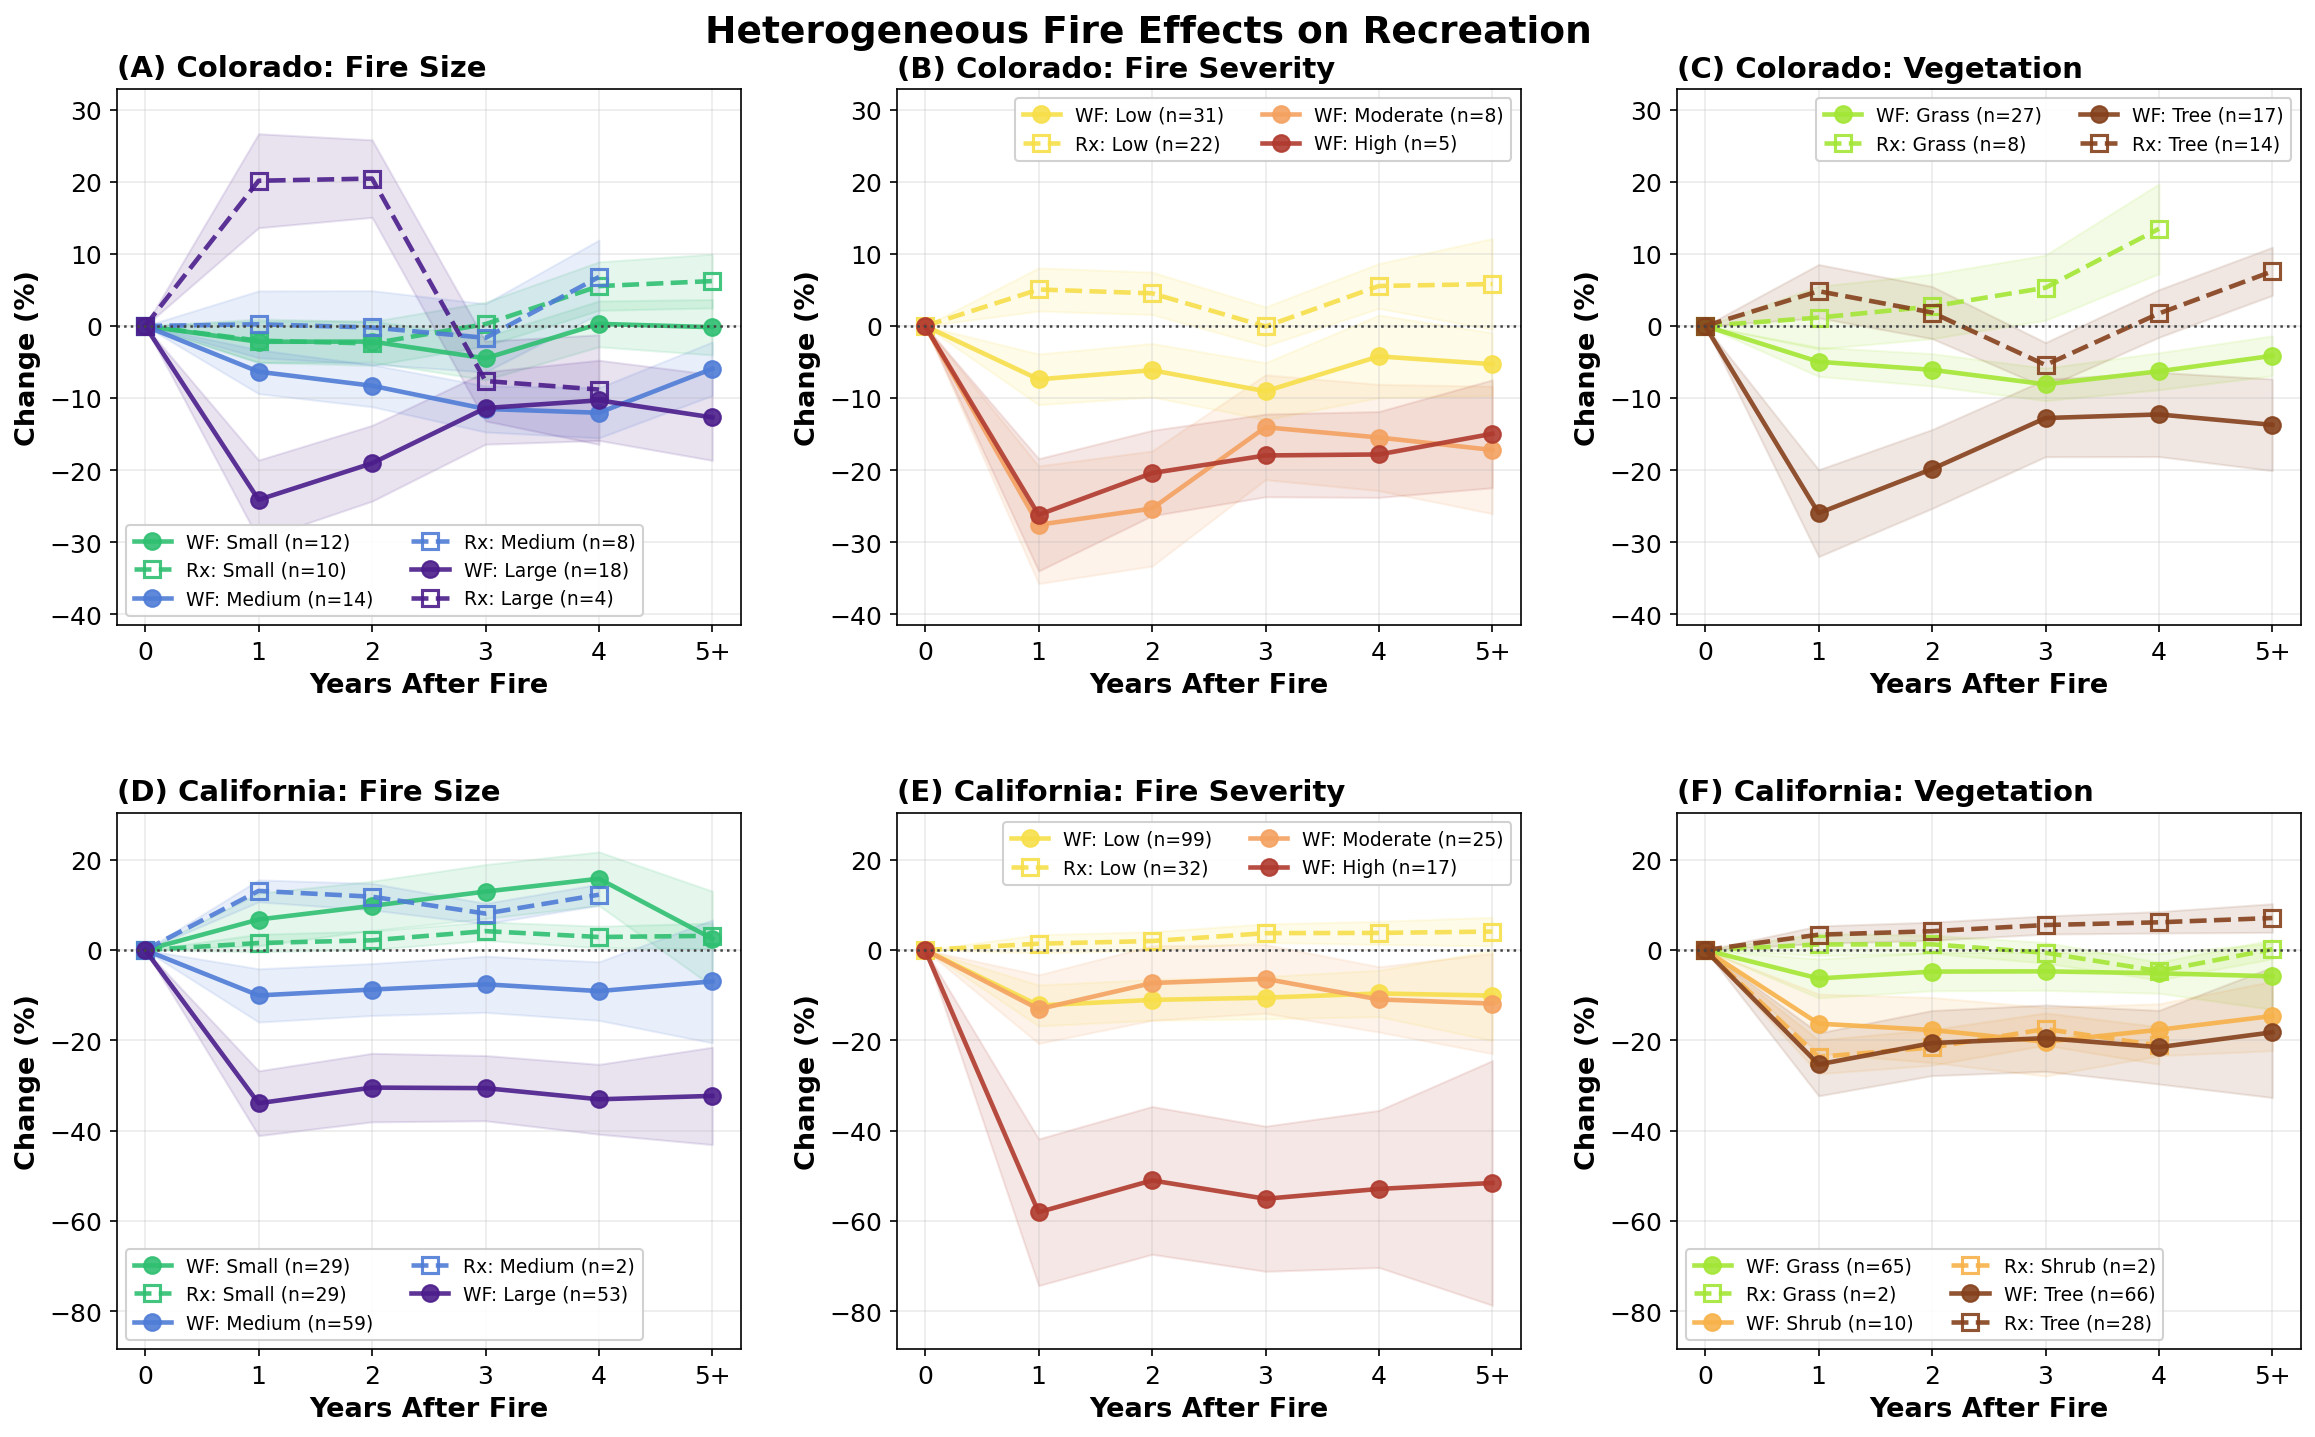


DONE


In [17]:
"""
Plot Heterogeneous Fire Effects
================================
Loads DiD results and creates publication-ready figures.

Displays in notebook and saves to files.
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import warnings

# Suppress any warnings
warnings.filterwarnings('ignore')
import warnings
import logging

# Suppress fontTools logging messages (from PDF creation)
logging.getLogger('fontTools').setLevel(logging.WARNING)
warnings.filterwarnings('ignore')
import logging

# Suppress font subsetting messages
logging.getLogger('fontTools.subset').setLevel(logging.WARNING)

# ============================================================
# SETTINGS
# ============================================================

# Where to load results from
RESULTS_CSV = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\did_heterogeneity_results.csv"

# Where to save figures
OUTPUT_DIR = r"C:\Users\kyma3609\OneDrive - UCB-O365\Recreation_Fire\final_figures"

# ============================================================
# FIGURE SETTINGS
# ============================================================

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": 600,
    "figure.dpi": 150,
    "font.size": 14,
    "font.family": "sans-serif",
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11,
})

# Colorblind-friendly colors
size_colors = {
    'small': '#2FBF71',   # Green
    'medium': '#4F7CD6',  # Blue
    'large': '#4B1D8B',   # Purple
}

sev_colors = {
    'low': '#F7DF4A',      # Yellow
    'moderate': '#F4A261', # Orange
    'high': '#B03A2E',     # Red
}

veg_colors = {
    'grass': '#A3E635',  # Lime green
    'shrub': '#F7B24A',  # Tan
    'tree': '#85411C',   # Brown
}

# ============================================================
# LOAD DATA
# ============================================================

print("=" * 60)
print("LOADING RESULTS")
print("=" * 60)

df = pd.read_csv(RESULTS_CSV)
print(f"\n✓ Loaded {len(df)} rows from {RESULTS_CSV}")
print(f"\nStates: {df['state'].unique()}")
print(f"Fire types: {df['fire_type'].unique()}")
print(f"Stratifications: {df['stratification'].unique()}")

# ============================================================
# CREATE FIGURE
# ============================================================

print("\n" + "=" * 60)
print("CREATING FIGURE: HETEROGENEOUS EFFECTS")
print("=" * 60)

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.25,
                       left=0.07, right=0.98, top=0.92, bottom=0.08)

def plot_panel(ax, state, stratification, category_colors, categories):
    """Plot one panel of the figure"""
    
    # Filter data
    panel_data = df[(df['state'] == state) & 
                    (df['stratification'] == stratification)]
    
    if len(panel_data) == 0:
        ax.text(0.5, 0.5, 'No data available', 
                ha='center', va='center', transform=ax.transAxes)
        return
    
    # Plot each category × fire type combination
    for category in categories:
        for ft in ['wildfire', 'prescribed']:
            
            data = panel_data[(panel_data['stratum'] == category) & 
                             (panel_data['fire_type'] == ft)]
            
            if len(data) == 0:
                continue
            
            # Sort by year
            data = data.sort_values('year')
            
            years = data['year'].values
            effects = data['effect_pct'].values
            ci_lower = data['ci_lower'].values
            ci_upper = data['ci_upper'].values
            n_treated = data['n_treated'].iloc[0] if len(data) > 0 else 0
            
            # Styling
            color = category_colors[category]
            linestyle = '-' if ft == 'wildfire' else '--'
            marker = 'o' if ft == 'wildfire' else 's'
            fillstyle = 'full' if ft == 'wildfire' else 'none'
            markeredgewidth = 1.5 if ft == 'prescribed' else 1.0
            
            ft_abbr = 'WF' if ft == 'wildfire' else 'Rx'
            label = f"{ft_abbr}: {category.capitalize()} (n={n_treated})"
            
            # Plot
            ax.plot(years, effects, marker=marker, markersize=8, linewidth=2.2,
                    linestyle=linestyle, color=color, label=label, alpha=0.9,
                    fillstyle=fillstyle, markeredgewidth=markeredgewidth, 
                    markeredgecolor=color)
            ax.fill_between(years, ci_lower, ci_upper, alpha=0.12, color=color)
    
    # Formatting
    ax.axhline(0, color='#424242', linestyle=':', linewidth=1.2)
    ax.set_xlabel('Years After Fire', fontsize=13, fontweight='bold')
    ax.set_ylabel('Change (%)', fontsize=13, fontweight='bold')
    ax.set_xticks(range(6))
    ax.set_xticklabels(['0', '1', '2', '3', '4', '5+'], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    ax.grid(alpha=0.25)
    ax.legend(loc='best', fontsize=9, ncol=2, framealpha=0.9)

# Row 1: Colorado
ax_co_size = fig.add_subplot(gs[0, 0])
plot_panel(ax_co_size, 'CO', 'size', size_colors, ['small', 'medium', 'large'])
ax_co_size.set_title('(A) Colorado: Fire Size', loc='left', fontsize=14, fontweight='bold')

ax_co_sev = fig.add_subplot(gs[0, 1])
plot_panel(ax_co_sev, 'CO', 'severity', sev_colors, ['low', 'moderate', 'high'])
ax_co_sev.set_title('(B) Colorado: Fire Severity', loc='left', fontsize=14, fontweight='bold')

ax_co_veg = fig.add_subplot(gs[0, 2])
plot_panel(ax_co_veg, 'CO', 'vegetation', veg_colors, ['grass', 'tree'])
ax_co_veg.set_title('(C) Colorado: Vegetation', loc='left', fontsize=14, fontweight='bold')

# Row 2: California
ax_ca_size = fig.add_subplot(gs[1, 0])
plot_panel(ax_ca_size, 'CA', 'size', size_colors, ['small', 'medium', 'large'])
ax_ca_size.set_title('(D) California: Fire Size', loc='left', fontsize=14, fontweight='bold')

ax_ca_sev = fig.add_subplot(gs[1, 1])
plot_panel(ax_ca_sev, 'CA', 'severity', sev_colors, ['low', 'moderate', 'high'])
ax_ca_sev.set_title('(E) California: Fire Severity', loc='left', fontsize=14, fontweight='bold')

ax_ca_veg = fig.add_subplot(gs[1, 2])
plot_panel(ax_ca_veg, 'CA', 'vegetation', veg_colors, ['grass', 'shrub', 'tree'])
ax_ca_veg.set_title('(F) California: Vegetation', loc='left', fontsize=14, fontweight='bold')

# Sync y-limits within rows
def sync_ylims(axes_list):
    """Make all axes in list have same y-limits"""
    all_lims = []
    for ax in axes_list:
        lims = ax.get_ylim()
        all_lims.extend(lims)
    
    if all_lims:
        ymin, ymax = min(all_lims), max(all_lims)
        span = ymax - ymin
        pad = 0.05 * span if span > 0 else 1
        for ax in axes_list:
            ax.set_ylim(ymin - pad, ymax + pad)

# Sync Colorado panels
sync_ylims([ax_co_size, ax_co_sev, ax_co_veg])

# Sync California panels
sync_ylims([ax_ca_size, ax_ca_sev, ax_ca_veg])

# Title
fig.suptitle('Heterogeneous Fire Effects on Recreation', 
             fontsize=18, fontweight='bold', y=0.97)

# Save high-resolution figures
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Standard publication quality (600 DPI)
fig.savefig(os.path.join(OUTPUT_DIR, 'Heterogeneous_Effects.png'), 
            bbox_inches='tight', dpi=600)
fig.savefig(os.path.join(OUTPUT_DIR, 'Heterogeneous_Effects.pdf'), 
            bbox_inches='tight')

# Ultra high-resolution for printing/posters (1200 DPI)
fig.savefig(os.path.join(OUTPUT_DIR, 'Heterogeneous_Effects_HighRes.png'), 
            bbox_inches='tight', dpi=1200)

print("\n✓ Saved figures to:", OUTPUT_DIR)
print("  • Heterogeneous_Effects.png (600 DPI)")
print("  • Heterogeneous_Effects.pdf (vector)")
print("  • Heterogeneous_Effects_HighRes.png (1200 DPI)")

# Display in notebook
plt.show()

print("\n" + "=" * 60)
print("DONE")
print("=" * 60)